<a href="https://colab.research.google.com/github/dilcetto/snli-ve-fusion-reliability/blob/main/thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Why Two Multimodal Models Disagree on the Same Image
### A case study in evaluating AI reliability under cross-modal contradiction

In [1]:
# ===================== ENVIRONMENT SETUP =====================
!pip install -q torch torchvision transformers accelerate
!pip install -q "bitsandbytes>=0.46.1"
!pip install -q datasets pillow requests pandas scipy matplotlib seaborn
# Suppress noisy library warnings (no functional effect; models/datasets are public,
# and CPU offloading of a few parameters is expected on a T4)
import warnings, logging
warnings.filterwarnings("ignore", message=".*HF_TOKEN.*")
warnings.filterwarnings("ignore", message=".*unauthenticated requests.*")
warnings.filterwarnings("ignore", message=".*device_map keys do not match.*")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("accelerate").setLevel(logging.ERROR)

print("Environment ready. Proceed to next cells.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.8 MB/s eta 0:00:00
Environment ready. Proceed to next cells.


### 1. Dataset: 1,000 stratified examples from SNLI-VE (500 entailment, 500 contradiction), streamed from the validation split. Labels 0 and 2 only; neutral excluded by design.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. LLaVA-1.5-7B: late fusion. 4-bit NF4 quantisation (T4 16GB VRAM limit). Prompt: yes/no question format.

In [2]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("sedrickkeh/snli-ve", split="validation", streaming=True)

consistent, contradiction = [], []

for item in dataset:
    label = item['label']

    if int(label) == 0 and len(consistent) < 500:
        consistent.append({
            'image': item['image'],
            'premise': item['premise'],
            'hypothesis': item['hypothesis'],
            'label': 'entailment'
        })
    elif int(label) == 2 and len(contradiction) < 500:
        contradiction.append({
            'image': item['image'],
            'premise': item['premise'],
            'hypothesis': item['hypothesis'],
            'label': 'contradiction'
        })

    if len(consistent) == 500 and len(contradiction) == 500:
        break

df = pd.DataFrame(consistent + contradiction)
print(f"Sample built: {len(df)} examples total.")
print(f"  Entailment: {len(df[df['label'] == 'entailment'])}")
print(f"  Contradiction: {len(df[df['label'] == 'contradiction'])}")



README.md:   0%|          | 0.00/780 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/149 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/149 [00:00<?, ?it/s]

Sample built: 1000 examples total.
  Entailment: 500
  Contradiction: 500


In [ ]:
from transformers import LlavaProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
import torch

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4", # Recommended 4-bit quantization type
    bnb_4bit_compute_dtype=torch.float16, # Compute in float16 for efficiency
    llm_int8_enable_fp32_cpu_offload=True # Explicitly enable CPU offload for 32-bit modules
)

processor = LlavaProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf")
model_llava = LlavaForConditionalGeneration.from_pretrained(
    "llava-hf/llava-1.5-7b-hf",
    quantization_config=quant_config,
    device_map="auto",
    torch_dtype=torch.float16 # Ensure model is loaded with float16 where applicable
)
def llava_predict(image, premise, hypothesis):
    prompt = "USER: <image>\nIs it true that " + hypothesis + "?\nAnswer yes or no.\nASSISTANT:"
    inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")
    out = processor.decode(model_llava.generate(**inputs, max_new_tokens=10)[0], skip_special_tokens=True)
    answer = out.split("ASSISTANT:")[-1].strip().lower()
    if "yes" in answer:
        return "entailment"
    else:
        return "contradiction"



Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

In [ ]:
import pandas as pd
from tqdm.auto import tqdm
import torch

# Rename the string column to avoid confusion
df.rename(columns={'label': 'condition'}, inplace=True)

results = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        llava_out = llava_predict(row['image'], row['premise'], row['hypothesis'])
    except Exception as e:
        llava_out = f"ERROR: {e}"


    results.append({
        "id": idx,
        "true_label": row['condition'],  # already 'entailment' or 'contradiction'
        "llava": llava_out
    })

    if (idx + 1) % 100 == 0:
        pd.DataFrame(results).to_csv('/content/drive/MyDrive/llava_only.csv', index=False)
        torch.cuda.empty_cache()

pd.DataFrame(results).to_csv('/content/drive/MyDrive/llava_only.csv', index=False)
print("Done!")


  0%|          | 0/1000 [00:00<?, ?it/s]

Done!


In [ ]:
import pandas as pd

df_check = pd.read_csv('/content/drive/MyDrive/llava_only.csv')

print(f"Total examples: {len(df_check)}")
print(f"\nCondition distribution:")
print(df_check['true_label'].value_counts())
print(f"\nLLaVA output distribution:")
print(df_check['llava'].value_counts())
print(f"\nAccuracy per condition:")
df_check['correct'] = (df_check['llava'] == df_check['true_label']).astype(int)
print(df_check.groupby('true_label')['correct'].mean().round(3))
print(f"\nFirst 10 rows:")
print(df_check.head(10))
print(df_check['llava'].str.startswith('ERROR').sum(), 'errors')

Total examples: 1000

Condition distribution:
true_label
entailment       500
contradiction    500
Name: count, dtype: int64

LLaVA output distribution:
llava
entailment       514
contradiction    486
Name: count, dtype: int64

Accuracy per condition:
true_label
contradiction    0.910
entailment       0.938
Name: correct, dtype: float64

First 10 rows:
   id  true_label       llava  correct
0   0  entailment  entailment        1
1   1  entailment  entailment        1
2   2  entailment  entailment        1
3   3  entailment  entailment        1
4   4  entailment  entailment        1
5   5  entailment  entailment        1
6   6  entailment  entailment        1
7   7  entailment  entailment        1
8   8  entailment  entailment        1
9   9  entailment  entailment        1


In [ ]:
import torch, gc, shutil
del model_llava, processor
gc.collect()
torch.cuda.empty_cache()
shutil.rmtree("/root/.cache/huggingface/hub", ignore_errors=True)
import psutil
disk = psutil.disk_usage('/')
print(f"Free: {disk.free / 1e9:.1f} GB")


Free: 70.1 GB


### 3. BLIP-2-OPT-2.7B: intermediate fusion via Q-Former. Runs fp16 (fits the T4 unquantised; a documented asymmetry with LLaVA, see thesis 4.7.5). Prompt: completion format, not a question; question formats produced unparseable output (see prompt experiments below).

In [ ]:
from datasets import load_dataset
import pandas as pd
# Same 1,000-example sample as the LLaVA section, rebuilt so this section is self-contained and both models score the identical pairs.
dataset = load_dataset("sedrickkeh/snli-ve", split="validation", streaming=True)
consistent, contradiction = [], []
for item in dataset:
    label = item['label']
    if int(label) == 0 and len(consistent) < 500:
        consistent.append({'image': item['image'], 'premise': item['premise'],
                           'hypothesis': item['hypothesis'], 'label': 'entailment'})
    elif int(label) == 2 and len(contradiction) < 500:
        contradiction.append({'image': item['image'], 'premise': item['premise'],
                              'hypothesis': item['hypothesis'], 'label': 'contradiction'})
    if len(consistent) == 500 and len(contradiction) == 500:
        break
df = pd.DataFrame(consistent + contradiction)
df.rename(columns={'label': 'condition'}, inplace=True)


README.md:   0%|          | 0.00/780 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/149 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/149 [00:00<?, ?it/s]

In [4]:
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration

processor_b2 = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model_b2 = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

def blip2_predict(image, hypothesis):
    prompt = f"{hypothesis} The answer is"
    inputs = processor_b2(text=prompt, images=image, return_tensors="pt").to("cuda")
    out = processor_b2.decode(model_b2.generate(**inputs, max_new_tokens=3)[0], skip_special_tokens=True)
    answer = out[len(prompt):].strip().lower()
    if "yes" in answer:
        return "entailment"
    else:
        return "contradiction"


model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [ ]:
# Test entailment example
img_e = df.iloc[0]['image']
h_e = df.iloc[0]['hypothesis']
print(f"=== Entailment test ===")
print(f"Hypothesis: {h_e}")
print(f"BLIP-2: {blip2_predict(img_e, h_e)}")
print(f"Expected: entailment\n")

# Test contradiction example
img_c = df.iloc[500]['image']
h_c = df.iloc[500]['hypothesis']
print(f"=== Contradiction test ===")
print(f"Hypothesis: {h_c}")
print(f"BLIP-2: {blip2_predict(img_c, h_c)}")
print(f"Expected: contradiction\n")

# Quick accuracy check on 10 random examples
import random
random.seed(42)
correct = 0
for _ in range(10):
    idx = random.randint(0, 999)
    row = df.iloc[idx]
    pred = blip2_predict(row['image'], row['hypothesis'])
    is_correct = 1 if pred == row['condition'] else 0
    correct += is_correct

print(f"10 random examples — accuracy: {correct}/10")


=== Entailment test ===
Hypothesis: A toddler poses in front of a computer indoors.
BLIP-2: entailment
Expected: entailment

=== Contradiction test ===
Hypothesis: A toddler sleeps outside.
BLIP-2: entailment
Expected: contradiction

10 random examples — accuracy: 7/10


In [ ]:
# Test different prompts on one entailment and one contradiction example
img_e = df.iloc[0]['image']
h_e = df.iloc[0]['hypothesis']
img_c = df.iloc[500]['image']
h_c = df.iloc[500]['hypothesis']

formats = [
    f"Question: Is it true that {h_e}?\nAnswer yes or no.",
    f"Is it true that {h_e}? Answer yes or no.",
    f"Does the image show: {h_e}? yes or no?",
    f"True or false: {h_e}",
]

for i, prompt in enumerate(formats):
    # Test on entailment
    inputs = processor_b2(text=prompt, images=img_e, return_tensors="pt").to("cuda")
    out = processor_b2.decode(model_b2.generate(**inputs, max_new_tokens=10)[0], skip_special_tokens=True)
    pred = out.strip().lower()

    # Test on contradiction (replace hypothesis)
    prompt_c = prompt.replace(h_e, h_c)
    inputs_c = processor_b2(text=prompt_c, images=img_c, return_tensors="pt").to("cuda")
    out_c = processor_b2.decode(model_b2.generate(**inputs_c, max_new_tokens=10)[0], skip_special_tokens=True)
    pred_c = out_c.strip().lower()

    print(f"Format {i+1}: entailment={pred} | contradiction={pred_c}")


Format 1: entailment=question: is it true that a toddler poses in front of a computer indoors.?
answer yes or no. | contradiction=question: is it true that a toddler sleeps outside.?
answer yes or no.
Format 2: entailment=is it true that a toddler poses in front of a computer indoors.? answer yes or no. | contradiction=is it true that a toddler sleeps outside.? answer yes or no.
Format 3: entailment=does the image show: a toddler poses in front of a computer indoors.? yes or no? | contradiction=does the image show: a toddler sleeps outside.? yes or no?
Format 4: entailment=true or false: a toddler poses in front of a computer indoors. | contradiction=true or false: a toddler sleeps outside.


In [ ]:
# Test: force a yes/no by giving it the first word
img_e = df.iloc[0]['image']
h_e = df.iloc[0]['hypothesis']
img_c = df.iloc[500]['image']
h_c = df.iloc[500]['hypothesis']

tests = [
    f"{h_e} The answer is",
    f"Is this correct? {h_e} The answer is",
    f"The statement \"{h_e}\" is",
    f"Based on the image, the statement is: {h_e} This statement is",
]

for prompt in tests:
    inputs = processor_b2(text=prompt, images=img_e, return_tensors="pt").to("cuda")
    out = processor_b2.decode(model_b2.generate(**inputs, max_new_tokens=3)[0], skip_special_tokens=True)
    pred = out[len(prompt):].strip().lower()[:10]

    prompt_c = prompt.replace(h_e, h_c)
    inputs_c = processor_b2(text=prompt_c, images=img_c, return_tensors="pt").to("cuda")
    out_c = processor_b2.decode(model_b2.generate(**inputs_c, max_new_tokens=3)[0], skip_special_tokens=True)
    pred_c = out_c[len(prompt_c):].strip().lower()[:10]

    print(f"Prompt: {prompt[:60]}...")
    print(f"  entailment: '{pred}' | contradiction: '{pred_c}'\n")


Prompt: A toddler poses in front of a computer indoors. The answer i...
  entailment: '"yes"' | contradiction: 'no.'

Prompt: Is this correct? A toddler poses in front of a computer indo...
  entailment: 'no.' | contradiction: 'no.'

Prompt: The statement "A toddler poses in front of a computer indoor...
  entailment: 'written on' | contradiction: 'written on'

Prompt: Based on the image, the statement is: A toddler poses in fro...
  entailment: 'based on t' | contradiction: 'not true.'



In [ ]:
from tqdm.auto import tqdm

results = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        b2_out = blip2_predict(row['image'], row['hypothesis'])
    except Exception as e:
        b2_out = f"ERROR: {e}"
    results.append({"id": idx, "true_label": row['condition'], "blip2": b2_out})
    if (idx + 1) % 100 == 0:
        pd.DataFrame(results).to_csv('/content/drive/MyDrive/blip2_only.csv', index=False)

pd.DataFrame(results).to_csv('/content/drive/MyDrive/blip2_only.csv', index=False)


  0%|          | 0/1000 [00:00<?, ?it/s]

### 4. Analysis: per-condition accuracy, accuracy gaps, and 95% confidence intervals. Results CSVs are loaded from Drive; no re-inference needed.

=== Accuracy per condition ===
                LLaVA  BLIP-2
true_label                  
contradiction  0.910   0.832
entailment     0.938   0.260

=== Accuracy gaps (entailment - contradiction) ===
  LLaVA: 0.938 - 0.910 = 0.028
  BLIP-2: 0.260 - 0.832 = -0.572


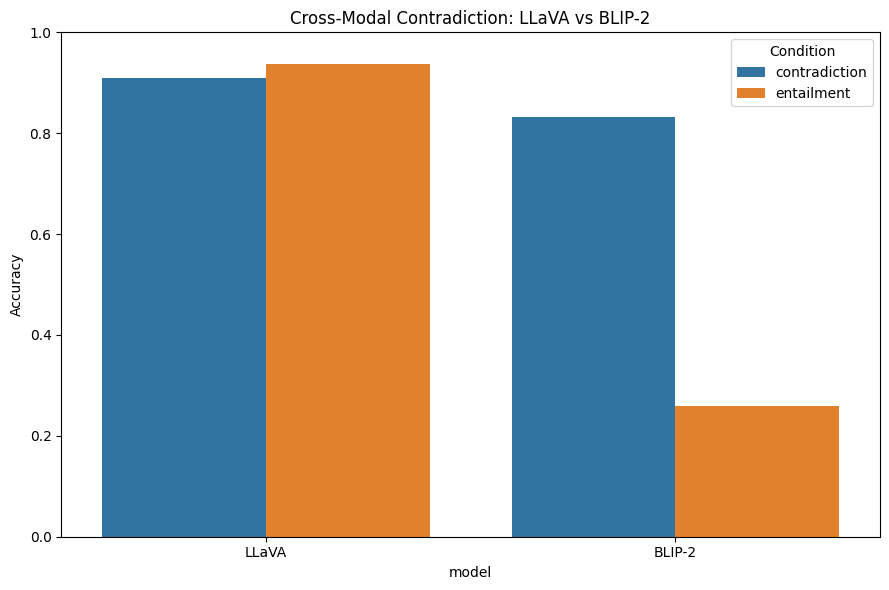

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load both results
llava = pd.read_csv('/content/drive/MyDrive/llava_only.csv')
blip2 = pd.read_csv('/content/drive/MyDrive/blip2_only.csv')
print(blip2['blip2'].str.startswith('ERROR').sum(), 'errors')
# Merge on id
merged = llava.merge(blip2, on=['id', 'true_label'], suffixes=('_llava', '_blip2'))
merged.rename(columns={'llava': 'llava_pred', 'blip2': 'blip2_pred'}, inplace=True)

# Score both models
for m in ['llava_pred', 'blip2_pred']:
    merged[f'{m}_correct'] = (merged[m] == merged['true_label']).astype(int)

# Accuracy table
summary = merged.groupby('true_label')[
    ['llava_pred_correct', 'blip2_pred_correct']
].mean().round(3)
summary.columns = ['LLaVA', 'BLIP-2']
print("=== Accuracy per condition ===\n", summary)

# Gaps
print("\n=== Accuracy gaps (entailment - contradiction) ===")
for name, col in [('LLaVA', 'llava_pred_correct'), ('BLIP-2', 'blip2_pred_correct')]:
    e = merged[merged['true_label']=='entailment'][col].mean()
    c = merged[merged['true_label']=='contradiction'][col].mean()
    print(f"  {name}: {e:.3f} - {c:.3f} = {e-c:.3f}")

### Thesis Figure 5.1: per-condition accuracy with 95% CI (the figure used in the case study).

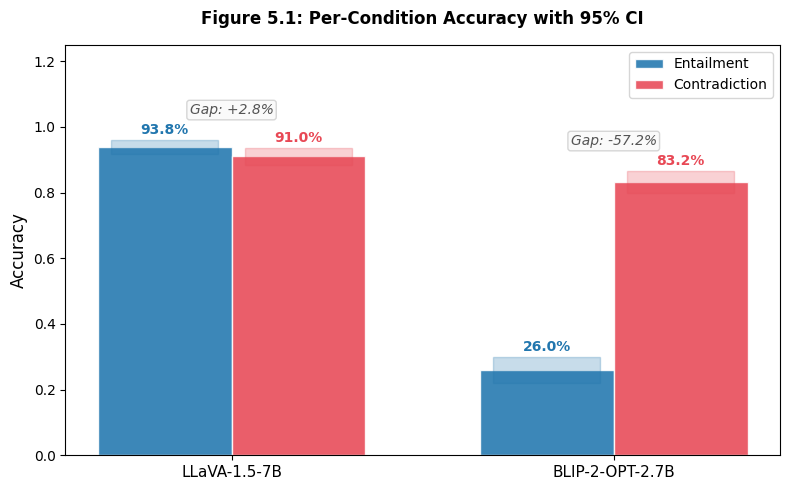

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- 1. Load Data ---
# Uses merged built in the analysis cell above. n=500 per condition by design; z=1.96 for 95% CI.
n = 500; z = 1.96
models = ['LLaVA-1.5-7B', 'BLIP-2-OPT-2.7B']
ent_acc = [merged[merged['true_label']=='entailment']['llava_pred_correct'].mean(),
           merged[merged['true_label']=='entailment']['blip2_pred_correct'].mean()]
con_acc = [merged[merged['true_label']=='contradiction']['llava_pred_correct'].mean(),
           merged[merged['true_label']=='contradiction']['blip2_pred_correct'].mean()]

# --- 2. Calculate Stats ---
def get_ci(p): return z * np.sqrt(p * (1 - p) / n)
ent_ci = [get_ci(p) for p in ent_acc]
con_ci = [get_ci(p) for p in con_acc]
gaps = [e - c for e, c in zip(ent_acc, con_acc)]

# --- 3. Plotting Figure 5.1b (Recommended Version) ---
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(models))
bw = 0.35
c_entail, c_contra = '#2176AE', '#E84855'

ax.bar(x - bw/2, ent_acc, bw, color=c_entail, label='Entailment', alpha=0.88, edgecolor='white')
ax.bar(x + bw/2, con_acc, bw, color=c_contra, label='Contradiction', alpha=0.88, edgecolor='white')

# Add shaded CI bands
for i in range(len(models)):
    ax.add_patch(mpatches.Rectangle((x[i]-bw/2-bw*0.4, ent_acc[i]-ent_ci[i]), bw*0.8, 2*ent_ci[i],
                                    color=c_entail, alpha=0.25))
    ax.add_patch(mpatches.Rectangle((x[i]+bw/2-bw*0.4, con_acc[i]-con_ci[i]), bw*0.8, 2*con_ci[i],
                                    color=c_contra, alpha=0.25))
    # Labels
    ax.text(x[i]-bw/2, ent_acc[i]+ent_ci[i]+0.02, f'{ent_acc[i]:.1%}', ha='center', fontweight='bold', color=c_entail)
    ax.text(x[i]+bw/2, con_acc[i]+con_ci[i]+0.02, f'{con_acc[i]:.1%}', ha='center', fontweight='bold', color=c_contra)
    # Gap Box
    ymax = max(ent_acc[i]+ent_ci[i], con_acc[i]+con_ci[i])
    ax.text(x[i], ymax+0.08, f'Gap: {gaps[i]:+.1%}', ha='center', style='italic', color='#555',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f9f9f9', edgecolor='#ccc', alpha=0.8))

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.25)
ax.set_title('Figure 5.1: Per-Condition Accuracy with 95% CI', fontweight='bold', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig5_1_final.png', dpi=300)
plt.show()
